## Cardiovascular disease prediction

Dataset: https://www.kaggle.com/datasets/mobeenfatimah/cardiovascular-disease-risk-prediction-dataset

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.base import clone

from pathlib import Path

## 2. Load dataset

In [2]:
path = Path("cardiovascular_disease_prediction.csv")
df = pd.read_csv(path)

print("Dataset Loaded Successfully!")

print("\nShape:", df.shape)

Dataset Loaded Successfully!

Shape: (20000, 35)


In [3]:
pd.set_option("display.max_columns", None)
df.head(10)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart_Rate,Cholesterol,HDL,LDL,Triglycerides,Blood_Glucose,Diabetes,Hypertension,Smoking,Alcohol_Consumption,Physical_Activity,Exercise_Days_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Stress_Level,Family_History,Chest_Pain,Shortness_of_Breath,ECG_Result,Medication,Diet_Quality,Annual_Income_USD,Region,Education_Level,BMI_Category,Risk_Score,Cardiovascular_Disease
0,110651,41,Female,165.6,89.0,32.5,118,79,85,248,44.0,NaN,255.0,93.0,No,No,Yes,No,Moderate,7,56,8.5,High,No,No,No,Normal,No,Average,109870,Central,Bachelor,Obese,7.63,0
1,102042,43,Female,163.1,40.0,15.0,114,55,73,219,58.0,96.0,176.0,75.0,No,No,No,No,Moderate,2,42,7.0,Low,No,No,Yes,Normal,No,Poor,33025,North,Master,Underweight,2.96,0
2,108669,37,Female,154.0,96.2,40.6,127,74,68,219,23.0,107.0,231.0,118.0,No,No,Yes,Yes,Low,5,82,7.7,Moderate,No,No,No,Normal,No,Poor,53705,South,Bachelor,Obese,9.73,0
3,101115,81,Female,168.7,72.8,25.6,137,87,70,154,49.0,102.0,207.0,NaN,Yes,No,Yes,No,Moderate,4,111,8.0,Moderate,Yes,Yes,Yes,Normal,Yes,Average,172645,West,Bachelor,Overweight,15.81,1
4,113903,32,Female,176.7,53.1,17.0,144,79,66,225,58.0,96.0,136.0,121.0,No,Yes,Yes,No,Moderate,5,56,6.5,Moderate,Yes,No,No,Normal,Yes,Average,93228,West,High School,Underweight,9.40,0
5,111964,25,Female,164.4,55.8,20.6,127,84,66,211,49.0,84.0,228.0,NaN,No,No,No,No,Moderate,2,100,6.5,Moderate,Yes,Yes,Yes,Normal,Yes,Poor,29821,West,Master,Normal,8.77,0
6,111073,81,Female,173.6,93.2,30.9,126,77,73,247,45.0,148.0,50.0,110.0,No,No,Yes,No,Low,3,19,6.7,Moderate,Yes,No,Yes,Abnormal,No,Average,174178,East,High School,Obese,18.04,1
7,103003,64,Male,170.2,83.7,28.9,148,84,94,181,74.0,142.0,200.0,140.0,Yes,Yes,No,No,High,3,33,6.9,High,No,No,No,Normal,No,Healthy,122155,Central,Bachelor,Overweight,12.05,1
8,119772,65,Male,171.7,66.9,22.7,107,65,80,254,45.0,121.0,217.0,78.0,Yes,No,No,Yes,Moderate,6,110,6.3,Low,Yes,No,No,Normal,No,Healthy,85685,East,Bachelor,Normal,7.53,0
9,108116,44,Female,169.9,81.8,28.3,137,102,81,254,73.0,135.0,143.0,139.0,Yes,No,Yes,Yes,Moderate,6,69,5.0,Moderate,No,Yes,No,Normal,No,NaN,54382,North,High School,Overweight,14.00,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                20000 non-null  int64  
 1   Age                       20000 non-null  int64  
 2   Gender                    20000 non-null  str    
 3   Height_cm                 20000 non-null  float64
 4   Weight_kg                 20000 non-null  float64
 5   BMI                       19400 non-null  float64
 6   Blood_Pressure_Systolic   20000 non-null  int64  
 7   Blood_Pressure_Diastolic  20000 non-null  int64  
 8   Heart_Rate                20000 non-null  int64  
 9   Cholesterol               20000 non-null  int64  
 10  HDL                       19400 non-null  float64
 11  LDL                       19400 non-null  float64
 12  Triglycerides             19400 non-null  float64
 13  Blood_Glucose             19400 non-null  float64
 14  Diabetes         

## 3. Check for duplicates

In [5]:
print("Number of duplicates:", df["Patient_ID"].duplicated().sum())

Number of duplicates: 0


## 4. Correlation Heatmap

- No strong correlation except BMI, Height_cm and Weight_kg (since BMI = Weight/Height**2)
- Also, Risk_score and Cardiovascular_Disease have strong positive correlation (Risk_score is possibily a leakage)

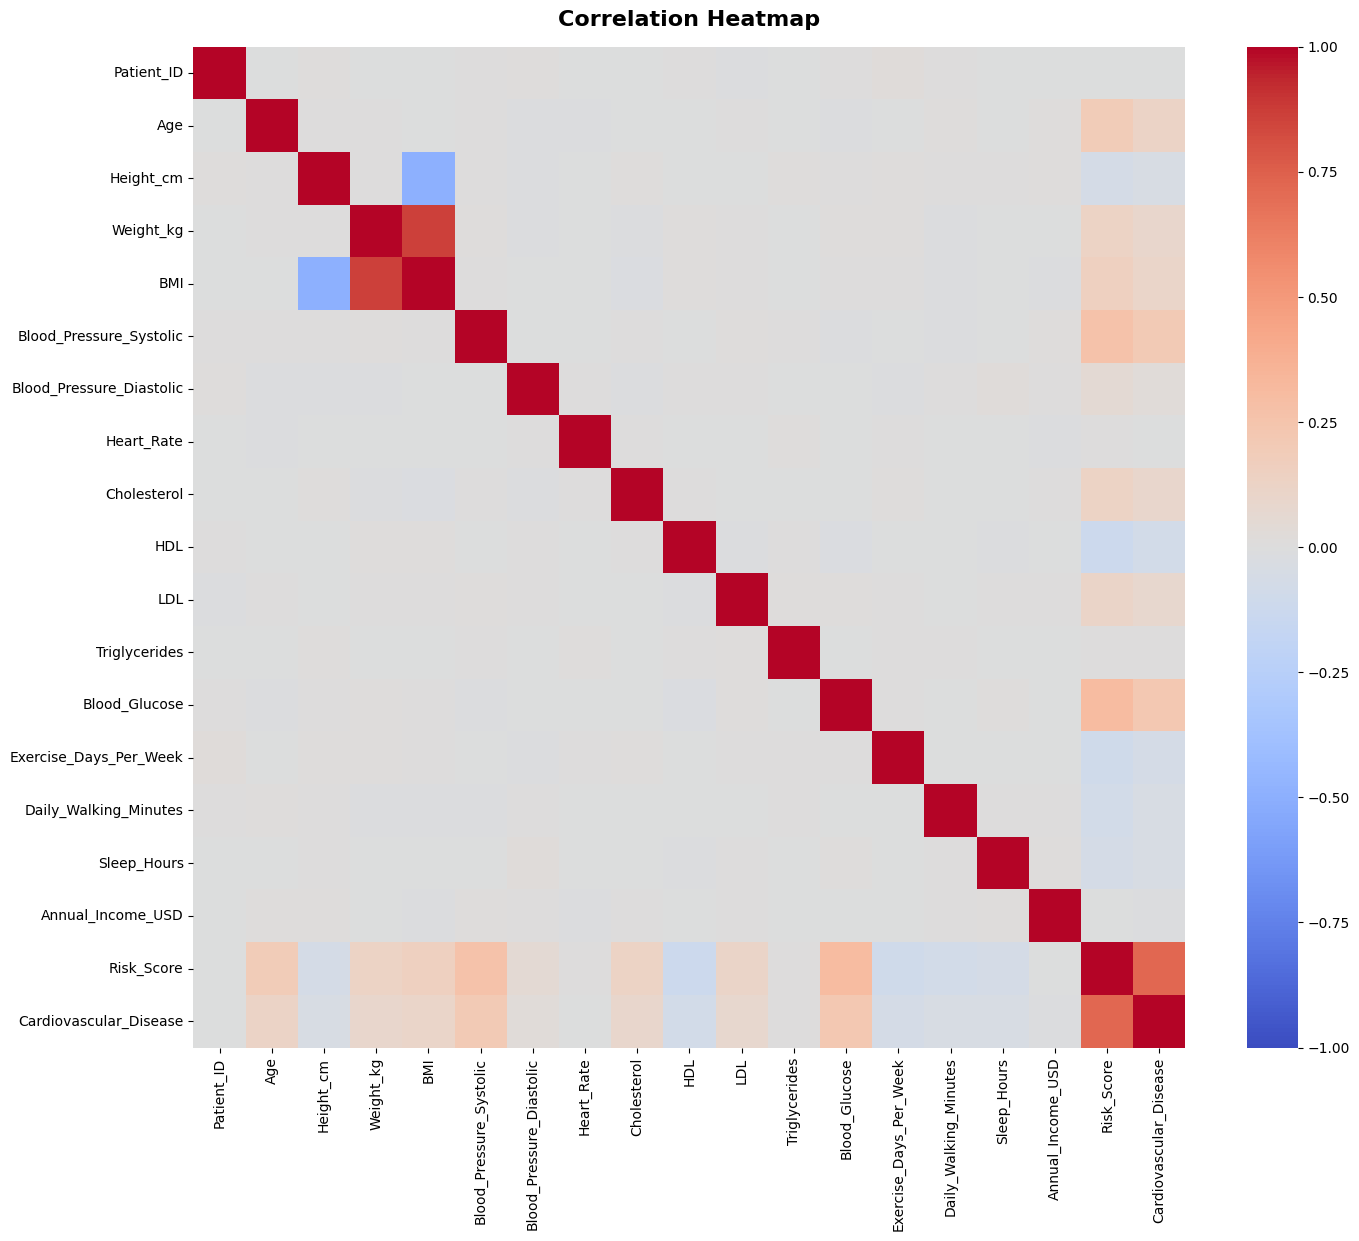

In [6]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(16,13))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.show()

## 5. Missing data columns analysis

In [7]:
missing = df.isnull().sum()[df.isnull().sum()>0]
print(missing)

BMI                  600
HDL                  600
LDL                  600
Triglycerides        600
Blood_Glucose        600
Physical_Activity    600
Sleep_Hours          600
Diet_Quality         600
dtype: int64


In [8]:
missing_cols = [
    "BMI", 
    "HDL", 
    "LDL", 
    "Triglycerides", 
    "Blood_Glucose", 
    "Physical_Activity", 
    "Sleep_Hours", 
    "Diet_Quality"
]

# Check if those missing values are from the same rows
display(df[missing_cols].head(10))

,BMI,HDL,LDL,Triglycerides,Blood_Glucose,Physical_Activity,Sleep_Hours,Diet_Quality
0,32.5,44.0,NaN,255.0,93.0,Moderate,8.5,Average
1,15.0,58.0,96.0,176.0,75.0,Moderate,7.0,Poor
2,40.6,23.0,107.0,231.0,118.0,Low,7.7,Poor
3,25.6,49.0,102.0,207.0,NaN,Moderate,8.0,Average
4,17.0,58.0,96.0,136.0,121.0,Moderate,6.5,Average
5,20.6,49.0,84.0,228.0,NaN,Moderate,6.5,Poor
6,30.9,45.0,148.0,50.0,110.0,Low,6.7,Average
7,28.9,74.0,142.0,200.0,140.0,High,6.9,Healthy
8,22.7,45.0,121.0,217.0,78.0,Moderate,6.3,Healthy
9,28.3,73.0,135.0,143.0,139.0,Moderate,5.0,NaN


## 5.1. Analysing BMI column

In [9]:
df["calculated_BMI"] = round(df["Weight_kg"]/((df["Height_cm"]/100)**2),1)

body = ["Weight_kg", "Height_cm", "BMI", "calculated_BMI"]
display(df[body].tail(20))

,Weight_kg,Height_cm,BMI,calculated_BMI
19980,81.1,184.5,23.8,23.8
19981,49.2,175.8,15.9,15.9
19982,55.8,165.0,20.5,20.5
19983,57.3,163.5,21.4,21.4
19984,56.6,156.2,NaN,23.2
19985,45.6,146.1,21.4,21.4
19986,70.9,183.2,21.1,21.1
19987,97.5,164.4,36.1,36.1
19988,43.1,171.4,14.7,14.7
19989,70.3,171.8,23.8,23.8


## 5.2. Analysing Blood Glucose column

In [10]:
df["Glucose_Range"] = pd.cut(
    df["Blood_Glucose"],
    bins=[0, 60, 70, 80, 90, 100, 125, float("inf")],
    labels=[
        "0-60",
        "61-70",
        "71-80",
        "81-90",
        "91-100",
        "101–125",
        "126 or above"
    ]
)

glucose_diabetes_table = pd.crosstab(
    df["Glucose_Range"],
    df["Diabetes"],
    margins=True
)

display(glucose_diabetes_table)

Diabetes,No,Yes,All
Glucose_Range,,,
0-60,1207,113,1320
61-70,992,90,1082
71-80,1490,145,1635
81-90,2010,162,2172
91-100,2220,211,2431
101–125,5571,476,6047
126 or above,0,4713,4713
All,13490,5910,19400


## 5.3. Analysing Physical Activity column

In [11]:
exercise = [
    "Physical_Activity",
    "Exercise_Days_Per_Week",
    "Daily_Walking_Minutes"
]

display(df[exercise].head(10))

,Physical_Activity,Exercise_Days_Per_Week,Daily_Walking_Minutes
0,Moderate,7,56
1,Moderate,2,42
2,Low,5,82
3,Moderate,4,111
4,Moderate,5,56
5,Moderate,2,100
6,Low,3,19
7,High,3,33
8,Moderate,6,110
9,Moderate,6,69


In [12]:
activity_summary = (
    df.dropna(subset=["Physical_Activity"])
      .groupby("Physical_Activity")[
          ["Exercise_Days_Per_Week", "Daily_Walking_Minutes"]
      ]
      .mean()
      .round(2)
)

display(activity_summary)

,Exercise_Days_Per_Week,Daily_Walking_Minutes
Physical_Activity,,
High,3.46,60.14
Low,3.52,59.38
Moderate,3.52,59.73


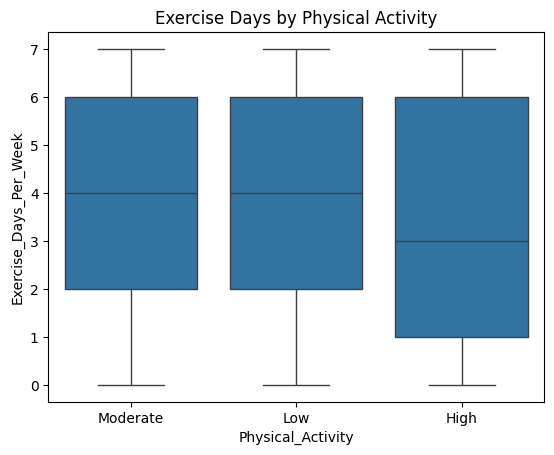

In [13]:
sns.boxplot(
    data=df,
    x="Physical_Activity",
    y="Exercise_Days_Per_Week"
)

plt.title("Exercise Days by Physical Activity")
plt.show()

I investigated whether "Exercise_Days_Per_Week" and "Daily_Walking_Minutes" could be used to impute missing "Physical_Activity" values. 

However, the mean exercise days and walking minutes were nearly identical across the Low, Moderate, and High activity groups. 

The distributions also overlapped heavily, indicating that these variables could not reliably distinguish the activity categories. Therefore, I did not use them to derive the missing values.

## 6. Who are the patients?

- The older age categories contain a relatively large proportion of patients.
- Normal BMI is the largest BMI category, although it does not contain a majority of all patients.
- Gender and region are relatively evenly represented.

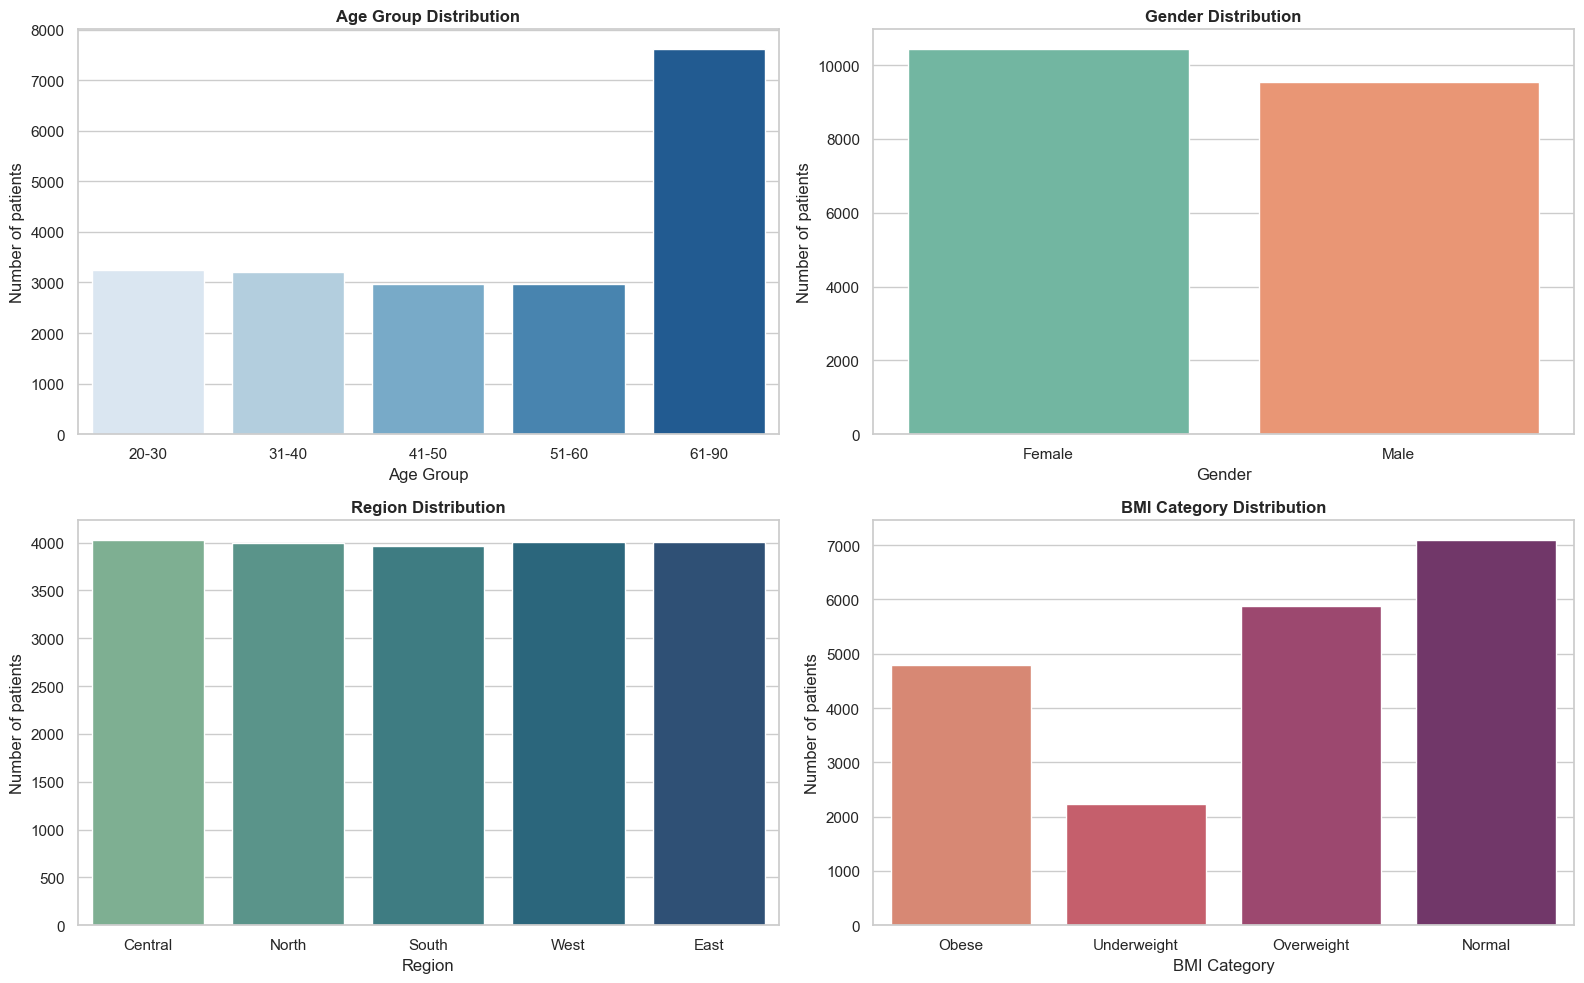

In [14]:
# Age group
df["age_group"] = pd.cut(
    df["Age"],
    bins=[19, 30, 40, 50, 60, 90],
    labels=[
        "20-30",
        "31-40",
        "41-50",
        "51-60",
        "61-90"
    ]
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16,10))

sns.countplot(
    data=df,
    x="age_group",
    hue="age_group",
    palette="Blues",
    dodge=False,
    ax=axes[0,0]
)

axes[0,0].set_title("Age Group Distribution", fontweight="bold")
axes[0,0].set_xlabel("Age Group")
axes[0,0].set_ylabel("Number of patients")

# Gender
sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette="Set2",
    ax=axes[0,1]
)

axes[0,1].set_title("Gender Distribution", fontweight="bold")
axes[0,1].set_xlabel("Gender")
axes[0,1].set_ylabel("Number of patients")

# Region
sns.countplot(
    data=df,
    x="Region",
    hue="Region",
    palette="crest",
    ax=axes[1,0]
)

axes[1,0].set_title("Region Distribution", fontweight="bold")
axes[1,0].set_xlabel("Region")
axes[1,0].set_ylabel("Number of patients")

# BMI_Category
sns.countplot(
    data=df,
    x="BMI_Category",
    hue="BMI_Category",
    palette="flare",
    ax=axes[1,1]
)

axes[1,1].set_title("BMI Category Distribution", fontweight="bold")
axes[1,1].set_xlabel("BMI Category")
axes[1,1].set_ylabel("Number of patients")

plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Heart_Rate',
       'Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Blood_Glucose',
       'Diabetes', 'Hypertension', 'Smoking', 'Alcohol_Consumption',
       'Physical_Activity', 'Exercise_Days_Per_Week', 'Daily_Walking_Minutes',
       'Sleep_Hours', 'Stress_Level', 'Family_History', 'Chest_Pain',
       'Shortness_of_Breath', 'ECG_Result', 'Medication', 'Diet_Quality',
       'Annual_Income_USD', 'Region', 'Education_Level', 'BMI_Category',
       'Risk_Score', 'Cardiovascular_Disease', 'calculated_BMI',
       'Glucose_Range', 'age_group'],
      dtype='str')

## 7. Prepare features and pipeline

In [16]:
target = "Cardiovascular_Disease"

columns_to_drop = [
    "Patient_ID",
    "Risk_Score",
    "BMI",
    "Cardiovascular_Disease",
    "Glucose_Range",
    "Medication"
]

X = df.drop(columns=columns_to_drop)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])


X shape: (20000, 32)
y shape: (20000,)


## 8. Compare models

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGboost": XGBClassifier(random_state=42),
    "SVC": SVC(random_state=42),
    "KNeighbors": KNeighborsClassifier()
}

results = []

for name, classifier in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "Model": name,
        "Accuracy": round(scores["test_accuracy"].mean(), 3),
        "Precision": round(scores["test_precision"].mean(), 3),
        "Recall": round(scores["test_recall"].mean(), 3),
        "F1": round(scores["test_f1"].mean(), 3),
        "F1_Std": round(scores["test_f1"].std(), 3),
        "ROC_AUC": round(scores["test_roc_auc"].mean(), 3)
    })

results_df = (
        pd.DataFrame(results)
        .sort_values("F1", ascending=False)
    )

display(results_df)

,Model,Accuracy,Precision,Recall,F1,F1_Std,ROC_AUC
3,Gradient Boost,0.892,0.911,0.717,0.803,0.008,0.940
5,SVC,0.882,0.843,0.756,0.797,0.008,0.931
4,XGboost,0.882,0.845,0.752,0.796,0.010,0.928
0,Logistic Regression,0.879,0.831,0.758,0.793,0.012,0.928
2,Random Forest,0.855,0.835,0.657,0.735,0.004,0.913
1,Decision Tree,0.764,0.614,0.616,0.615,0.016,0.723
6,KNeighbors,0.761,0.785,0.301,0.436,0.017,0.768


## 9. Tune Gradient Boosting

In [18]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

param_distributions = {
    "classifier__n_estimators": [50, 100, 150, 200, 300],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__max_depth": [1, 2, 3, 4, 5],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__max_features": [None, "sqrt", "log2"]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
    return_train_score=True
)

gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("\nBest mean CV F1:")
print(gb_search.best_score_)

tuning_results = pd.DataFrame(
    gb_search.cv_results_
)

tuning_results = tuning_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)

display(tuning_results.head(10))

Best parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 3, 'classifier__learning_rate': 0.2}

Best mean CV F1:
0.8440126073833907


,params,mean_test_score,std_test_score,rank_test_score
22,"{'classifier__subsample': 0.8, 'classifier__n_...",0.844013,0.010015,1
17,"{'classifier__subsample': 0.6, 'classifier__n_...",0.841405,0.011359,2
46,"{'classifier__subsample': 0.8, 'classifier__n_...",0.838710,0.007028,3
48,"{'classifier__subsample': 0.9, 'classifier__n_...",0.838516,0.009021,4
8,"{'classifier__subsample': 0.9, 'classifier__n_...",0.837682,0.011017,5
18,"{'classifier__subsample': 0.9, 'classifier__n_...",0.835726,0.009627,6
34,"{'classifier__subsample': 0.6, 'classifier__n_...",0.835642,0.010131,7
30,"{'classifier__subsample': 1.0, 'classifier__n_...",0.834054,0.007165,8
31,"{'classifier__subsample': 0.9, 'classifier__n_...",0.833349,0.009993,9
29,"{'classifier__subsample': 1.0, 'classifier__n_...",0.829316,0.010468,10


## 10. Final test evaluation

In [19]:
best_gb = gb_search.best_estimator_

y_pred = best_gb.predict(X_test)
y_probability = best_gb.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_probability)
)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.90675
Precision: 0.8885844748858448
Recall: 0.7949346405228758
F1: 0.8391548081069427
ROC AUC: 0.936021112335424

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2776
           1       0.89      0.79      0.84      1224

    accuracy                           0.91      4000
   macro avg       0.90      0.88      0.89      4000
weighted avg       0.91      0.91      0.91      4000


Confusion matrix:
[[2654  122]
 [ 251  973]]


## Final model interpretation

The tuned Gradient Boosting model achieved:

- Accuracy: 90.7%
- Precision: 88.9%
- Recall: 79.5%
- F1 score: 83.9%
- ROC AUC: 93.6%

Out of 1,224 patients with cardiovascular disease, the model
correctly identified 973 and missed 251.

Out of 2,776 patients without cardiovascular disease, 122 were
incorrectly flagged as positive.

The test F1 score of 0.839 was close to the cross-validation F1
score of 0.844, suggesting that the model generalised consistently
to the holdout test data.

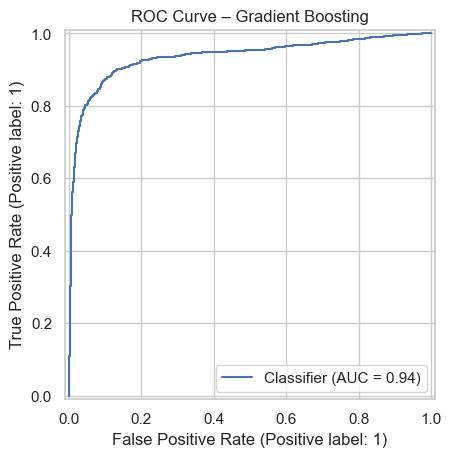

In [20]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve – Gradient Boosting")
plt.show()